# Asymmetric Clausius Constraint Analysis


In [1]:
from dataclasses import asdict
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

repo_root = Path("/Users/dajuarez4/Documents/QuarkMatt/nuclear_matter_workflows")
src_path = repo_root / "asymmetric_clausius_fit" / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from asymmetric_clausius_fit import (
    DEFAULT_CONSTANTS,
    DEFAULT_K0_TARGETS,
    compute_target_family,
    symmetric_clausius_point_from_c,
)

results_dir = repo_root / "results"
results_dir.mkdir(parents=True, exist_ok=True)

pd.set_option("display.precision", 6)
DEFAULT_K0_TARGETS


(250.0, 260.0, 270.0, 280.0, 290.0, 300.0, 310.0, 315.0)

## Model equations

For symmetric Clausius matter we keep the same structure as in the existing ground-state workflow,

- `f(n) = 1 - b n`
- `epsilon(n) = f(n) epsilon_id(n / f) - a n^2 / (1 + c n)`

For asymmetric matter we use

- `n = n_p + n_n`
- `x_p = b_n n_p + b_pn n_n`, `x_n = b_pn n_p + b_n n_n`
- `f_p = 1 - x_p`, `f_n = 1 - x_n`
- `epsilon(n,y) = f_p epsilon_p^id + f_n epsilon_n^id - [a_n (n_p^2 + n_n^2) + 2 a_pn n_p n_n] / (1 + c n)`

with the parabolic symmetry-energy convention

- `S(n) = E_PNM(n) - E_SNM(n)`
- `J = S(n0)`
- `L = 3 n0 dS/dn |_(n0)`


In [2]:
reference_c_values = [0.0, 1.185, 2.37, 3.555, 4.74]
reference_rows = [asdict(symmetric_clausius_point_from_c(c_value, DEFAULT_CONSTANTS)) for c_value in reference_c_values]
reference_df = pd.DataFrame(reference_rows)

existing_clausius_df = pd.read_csv(repo_root / "ground_state_ab_k0" / "results" / "clausius_ground_state.csv")
check_df = reference_df.merge(existing_clausius_df[["parameter_value", "a", "b", "K0"]], left_on="c", right_on="parameter_value", suffixes=("_analytic", "_existing"))
check_df["da"] = check_df["a_analytic"] - check_df["a_existing"]
check_df["db"] = check_df["b_analytic"] - check_df["b_existing"]
check_df["dK0"] = check_df["K0_analytic"] - check_df["K0_existing"]

display(reference_df[["c", "a", "b", "K0", "binding", "n_sat", "p_sat"]])
display(check_df[["c", "da", "db", "dK0"]])


,c,a,b,K0,binding,n_sat,p_sat
0,0.000,328.923321,3.414020,762.538953,-16.0,0.16,-3.323742e-07
1,1.185,366.587357,2.969233,538.602636,-16.0,0.16,3.191625e-07
2,2.370,402.890767,2.541070,401.808275,-16.0,0.16,-8.437782e-07
3,3.555,438.112247,2.127244,312.014209,-16.0,0.16,1.848912e-07
4,4.740,472.446297,1.725987,249.816855,-16.0,0.16,5.637487e-07


,c,da,db,dK0
0,0.000,-1.893682e-09,-9.964918e-12,1.918465e-07
1,1.185,-3.598757e-09,-1.961542e-11,1.314948e-06
2,2.370,3.063860e-09,1.712053e-11,-5.555556e-07
3,3.555,1.006299e-09,5.501377e-12,1.582734e-06
4,4.740,5.798654e-09,3.368616e-11,1.107114e-06


## Asymmetric Clausius fit in the empirical `K0` window

The solver below uses `K0` as the control parameter inside the range `250-315 MeV`. For each target value it returns the common Clausius parameter `c`, the symmetric averages `(a,b)`, and the asymmetric parameters `(a_n, a_pn, b_n, b_pn)`.


In [3]:
fit_results = compute_target_family(DEFAULT_K0_TARGETS, DEFAULT_CONSTANTS)
fit_df = pd.DataFrame(asdict(result) for result in fit_results)
fit_df["delta_a"] = 0.5 * (fit_df["a_pn"] - fit_df["a_n"])
fit_df["delta_b"] = 0.5 * (fit_df["b_pn"] - fit_df["b_n"])
fit_df["a_avg_check"] = 0.5 * (fit_df["a_n"] + fit_df["a_pn"])
fit_df["b_avg_check"] = 0.5 * (fit_df["b_n"] + fit_df["b_pn"])
fit_df["a_avg_error"] = fit_df["a_avg_check"] - fit_df["a_avg"]
fit_df["b_avg_error"] = fit_df["b_avg_check"] - fit_df["b_avg"]

fit_csv = results_dir / "asymmetric_clausius_fit_results.csv"
fit_df.to_csv(fit_csv, index=False)

display(
    fit_df[[
        "target_k0", "c", "a_avg", "b_avg",
        "a_n", "a_pn", "b_n", "b_pn",
        "ratio_a_pn_over_a_n", "ratio_b_pn_over_b_n",
        "J", "L", "binding", "n_sat",
    ]]
)
fit_csv


,target_k0,c,a_avg,b_avg,a_n,a_pn,b_n,b_pn,ratio_a_pn_over_a_n,ratio_b_pn_over_b_n,J,L,binding,n_sat
0,250.0,4.735853,472.327508,1.727371,259.413733,685.241282,1.316923,2.137819,2.641500,1.623344,32.5,58.9,-16.0,0.16
1,260.0,4.516312,466.026019,1.800838,256.197399,675.854639,1.351272,2.250404,2.638023,1.665397,32.5,58.9,-16.0,0.16
2,270.0,4.309453,460.064473,1.870418,253.177802,666.951144,1.384757,2.356079,2.634319,1.701439,32.5,58.9,-16.0,0.16
3,280.0,4.114108,454.412697,1.936450,250.336526,658.488869,1.417423,2.455476,2.630415,1.732352,32.5,58.9,-16.0,0.16
4,290.0,3.929255,449.044178,1.999231,247.657454,650.430902,1.449313,2.549149,2.626333,1.758867,32.5,58.9,-16.0,0.16
5,300.0,3.753994,443.935490,2.059026,245.126408,642.744572,1.480464,2.637588,2.622094,1.781596,32.5,58.9,-16.0,0.16
6,310.0,3.587529,439.065850,2.116069,242.730858,635.400842,1.510911,2.721226,2.617718,1.801050,32.5,58.9,-16.0,0.16
7,315.0,3.507371,436.714809,2.143624,241.580371,631.849247,1.525881,2.761368,2.615483,1.809688,32.5,58.9,-16.0,0.16


PosixPath('/Users/dajuarez4/Documents/QuarkMatt/nuclear_matter_workflows/results/asymmetric_clausius_fit_results.csv')

In [4]:
constraint_check_df = fit_df[[
    "target_k0", "K0", "k0_residual",
    "J", "j_residual",
    "L", "l_residual",
    "binding", "n_sat", "p_sat",
    "a_avg_error", "b_avg_error",
]].copy()
display(constraint_check_df)


,target_k0,K0,k0_residual,J,j_residual,L,l_residual,binding,n_sat,p_sat,a_avg_error,b_avg_error
0,250.0,250.000002,1.986050e-06,32.5,-9.394853e-09,58.9,-4.371394e-09,-16.0,0.16,4.356051e-07,0.000000e+00,0.000000e+00
1,260.0,260.000001,7.051406e-07,32.5,9.754331e-10,58.9,2.018496e-08,-16.0,0.16,-1.959590e-07,-5.684342e-14,0.000000e+00
2,270.0,269.999999,-1.149310e-06,32.5,3.152991e-09,58.9,-3.280000e-09,-16.0,0.16,2.115339e-08,0.000000e+00,0.000000e+00
3,280.0,280.000000,1.834337e-09,32.5,-3.338755e-09,58.9,-4.829999e-08,-16.0,0.16,8.648315e-07,0.000000e+00,0.000000e+00
4,290.0,290.000001,7.892700e-07,32.5,2.428010e-09,58.9,-3.007152e-09,-16.0,0.16,8.035542e-07,0.000000e+00,-2.220446e-16
5,300.0,300.000001,9.771853e-07,32.5,-3.431865e-09,58.9,1.044951e-07,-16.0,0.16,-8.795964e-07,0.000000e+00,0.000000e+00
6,310.0,310.000001,1.316979e-06,32.5,7.707968e-10,58.9,5.729235e-08,-16.0,0.16,-5.524639e-07,0.000000e+00,0.000000e+00
7,315.0,314.999999,-1.254931e-06,32.5,1.379135e-09,58.9,9.816723e-09,-16.0,0.16,5.488633e-07,5.684342e-14,0.000000e+00


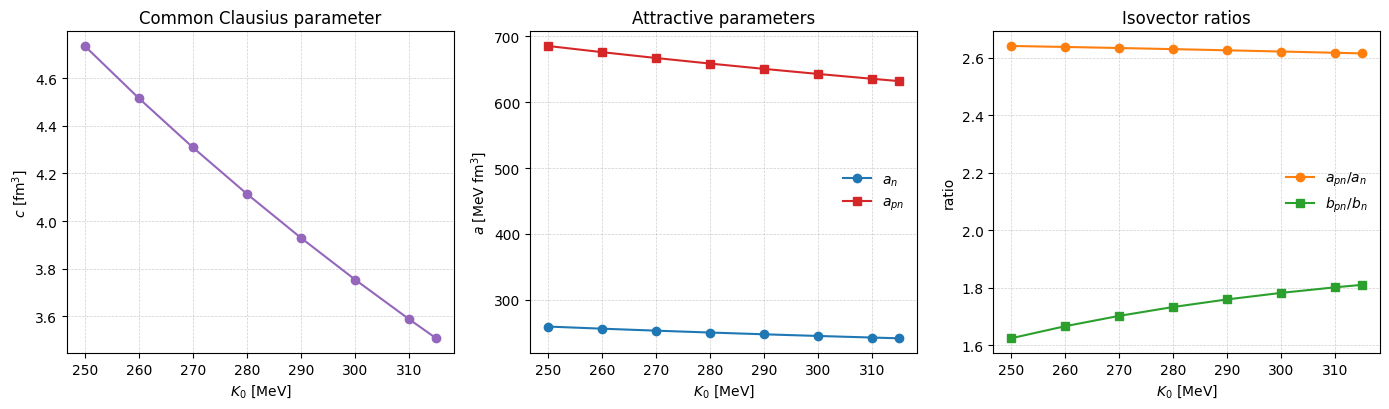

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

axes[0].plot(fit_df["K0"], fit_df["c"], marker="o", color="tab:purple")
axes[0].set_xlabel(r"$K_0$ [MeV]")
axes[0].set_ylabel(r"$c$ [fm$^3$]")
axes[0].set_title("Common Clausius parameter")

axes[1].plot(fit_df["K0"], fit_df["a_n"], marker="o", color="tab:blue", label=r"$a_n$")
axes[1].plot(fit_df["K0"], fit_df["a_pn"], marker="s", color="tab:red", label=r"$a_{pn}$")
axes[1].set_xlabel(r"$K_0$ [MeV]")
axes[1].set_ylabel(r"$a$ [MeV fm$^3$]")
axes[1].set_title("Attractive parameters")
axes[1].legend(frameon=False)

axes[2].plot(fit_df["K0"], fit_df["ratio_a_pn_over_a_n"], marker="o", color="tab:orange", label=r"$a_{pn}/a_n$")
axes[2].plot(fit_df["K0"], fit_df["ratio_b_pn_over_b_n"], marker="s", color="tab:green", label=r"$b_{pn}/b_n$")
axes[2].set_xlabel(r"$K_0$ [MeV]")
axes[2].set_ylabel("ratio")
axes[2].set_title("Isovector ratios")
axes[2].legend(frameon=False)

for ax in axes:
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)

plt.tight_layout()
fig.savefig(results_dir / "asymmetric_clausius_fit_summary.png", dpi=300)
plt.show()


In [6]:
paste_ready_df = fit_df[[
    "target_k0", "a_n", "a_pn", "b_n", "b_pn", "c",
    "ratio_a_pn_over_a_n", "ratio_b_pn_over_b_n",
]].copy()
paste_ready_csv = results_dir / "asymmetric_clausius_paste_ready.csv"
paste_ready_df.to_csv(paste_ready_csv, index=False)
display(paste_ready_df)
paste_ready_csv


,target_k0,a_n,a_pn,b_n,b_pn,c,ratio_a_pn_over_a_n,ratio_b_pn_over_b_n
0,250.0,259.413733,685.241282,1.316923,2.137819,4.735853,2.641500,1.623344
1,260.0,256.197399,675.854639,1.351272,2.250404,4.516312,2.638023,1.665397
2,270.0,253.177802,666.951144,1.384757,2.356079,4.309453,2.634319,1.701439
3,280.0,250.336526,658.488869,1.417423,2.455476,4.114108,2.630415,1.732352
4,290.0,247.657454,650.430902,1.449313,2.549149,3.929255,2.626333,1.758867
5,300.0,245.126408,642.744572,1.480464,2.637588,3.753994,2.622094,1.781596
6,310.0,242.730858,635.400842,1.510911,2.721226,3.587529,2.617718,1.801050
7,315.0,241.580371,631.849247,1.525881,2.761368,3.507371,2.615483,1.809688


PosixPath('/Users/dajuarez4/Documents/QuarkMatt/nuclear_matter_workflows/results/asymmetric_clausius_paste_ready.csv')